In [24]:

import pandas as pd

df = pd.read_csv("spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [25]:
%pip install deep-translator tqdm

Note: you may need to restart the kernel to use updated packages.


In [1]:
from deep_translator import GoogleTranslator
import pandas as pd
from tqdm import tqdm

tqdm.pandas()

# Load dataset
df = pd.read_csv("spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'message']

# Convert to string
df['message'] = df['message'].astype(str)

# Create balanced dataset
spam = df[df['label'] == 'spam'].sample(500, random_state=42)
ham = df[df['label'] == 'ham'].sample(500, random_state=42)

# Combine + shuffle
df = pd.concat([spam, ham]).sample(frac=1).reset_index(drop=True)

# Translate function
def translate_text(text):
    try:
        return GoogleTranslator(source='en', target='hi').translate(text)
    except:
        return text

print("Translating...")

# Apply translation
df['hindi'] = df['message'].progress_apply(translate_text)

# Save
df.to_csv("hindi_spam.csv", index=False)

print("✅ Done!")



Translating...


100%|██████████| 1000/1000 [11:51<00:00,  1.41it/s]

✅ Done!


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

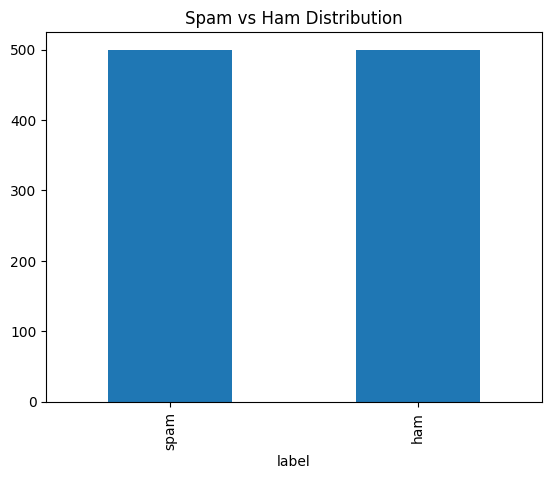

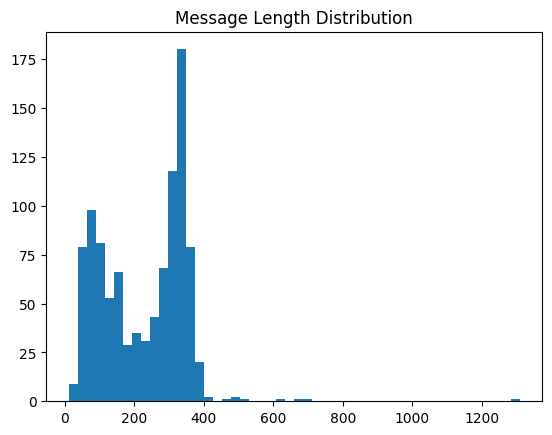

In [24]:
# Spam vs Ham
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.show()

# Message length
df['length'] = df['combined'].apply(len)

plt.hist(df['length'], bins=50)
plt.title("Message Length Distribution")
plt.show()

In [25]:
X = df['combined']
y = df['label'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [27]:
models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "SVM": svm
}

for name, model in models.items():
    y_pred = model.predict(X_test_vec)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       101
           1       0.94      0.94      0.94        99

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200


Naive Bayes
Accuracy: 0.945
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       101
           1       0.96      0.93      0.94        99

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200


SVM
Accuracy: 0.935
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       101
           1       0.94      0.93      0.93        99

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.9

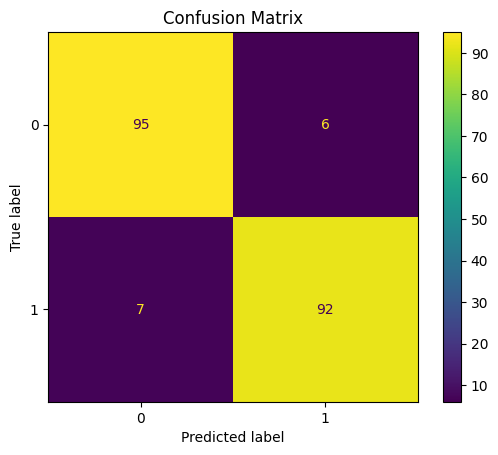

In [28]:
best_model = svm  # or whichever gave highest accuracy

ConfusionMatrixDisplay.from_estimator(best_model, X_test_vec, y_test)
plt.title("Confusion Matrix")
plt.show()

In [29]:
def predict_spam(text):
    text = str(text).lower()
    text_vec = vectorizer.transform([text])
    prediction = best_model.predict(text_vec)[0]
    
    return "🚨 Spam" if prediction == 1 else "✅ Not Spam"

In [30]:
print(predict_spam("आपने ₹5000 जीत लिए हैं अभी क्लिक करें"))
print(predict_spam("free offer click now"))
print(predict_spam("कल क्लास है"))
print(predict_spam("meeting at 6 pm"))

🚨 Spam
🚨 Spam
✅ Not Spam
✅ Not Spam
